In [18]:
import numpy as np

y = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

hist = np.bincount(y)
print(hist)

[5 9]


In [11]:
from collections import Counter

y = [0,0,1]
print(Counter(y).most_common(1)[0][0])

0


In [13]:
X = np.array([
    [0, 0, 0, 0],  # Sunny, Hot, High, False
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [2, 1, 0, 0],
    [2, 2, 1, 0],
    [2, 2, 1, 1],
    [1, 2, 1, 1],
    [0, 1, 0, 0],
    [0, 2, 1, 0],
    [2, 1, 1, 0],
    [0, 1, 1, 1],
    [1, 1, 0, 1],
    [1, 0, 1, 0],
    [2, 1, 0, 1],
])



4

In [17]:
thresholds = np.unique(X[:, X])
print(thresholds)

[0 1 2]


In [ ]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature           # Index of feature used for split
        self.threshold = threshold       # Value to split feature on
        self.left = left                 # Left subtree
        self.right = right               # Right subtree
        self.value = value               # Class prediction (if leaf)

def entropy(y):
    hist = np.bincount(y)
    ps = hist / len(y)
    return -np.sum([p * np.log2(p) for p in ps if p > 0])

def information_gain(y, left_idx, right_idx):
    parent_entropy = entropy(y)
    n = len(y)
    n_l, n_r = len(left_idx), len(right_idx)
    if n_l == 0 or n_r == 0:
        return 0
    e_l = entropy(y[left_idx])
    e_r = entropy(y[right_idx])
    child_entropy = (n_l/n) * e_l + (n_r/n) * e_r
    return parent_entropy - child_entropy

def build_tree(X, y, features=None):
    if features is None:
        features = list(range(X.shape[1]))
    # Stopping condition: all targets are the same, or no features left
    if len(set(y)) == 1 or len(features) == 0:
        value = Counter(y).most_common(1)[0][0]
        return Node(value=value)
    best_gain = -1
    best_feature = None
    best_threshold = None
    for feature in features:
        thresholds = np.unique(X[:, feature])
        for t in thresholds:
            left_idx = np.where(X[:, feature] <= t)[0]
            right_idx = np.where(X[:, feature] > t)[0]
            ig = information_gain(y, left_idx, right_idx)
            if ig > best_gain:
                best_gain, best_feature, best_threshold = ig, feature, t
    if best_gain == 0 or best_feature is None:
        # Couldn't find a valid split, so make a leaf node
        value = Counter(y).most_common(1)[0][0]
        return Node(value=value)
    left_idx = np.where(X[:, best_feature] <= best_threshold)[0]
    right_idx = np.where(X[:, best_feature] > best_threshold)[0]
    left = build_tree(X[left_idx], y[left_idx], features)
    right = build_tree(X[right_idx], y[right_idx], features)
    return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)


In [21]:
import numpy as np

class Node:
    def __init__(self , feature=None , threshold= None , right= None , left= None , value=None):
        self.feature = feature           
        self.threshold = threshold       
        self.left = left               
        self.right = right               
        self.value = value       

def entropy(y):
    arg = np.bincount(y)
    ps = arg / len(y)
    return -np.sum([p * np.log2(p) for p in ps])

def iG(y , left_idx , right_idx):
    parent_entropy = entropy(y)
    n = len(y)
    n_l = len(left_idx)
    n_r = len(right_idx)
    if n_l == 0 or n_r == 0:
        return 0
    e_l = entropy(left_idx)
        

In [22]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [2, 0],
    [2, 1]
])
y = np.array([0, 0, 1, 1, 0])

entropy(y)

0.9709505944546686

In [ ]:
import numpy as np

class Node:
    """A helper class to store information about each split/leaf."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature       # Index of the feature we split on
        self.threshold = threshold   # Value we split on
        self.left = left             # Left child node (<= threshold)
        self.right = right           # Right child node (> threshold)
        self.value = value           # If it's a leaf node, this holds the predicted mean

    def is_leaf(self):
        return self.value is not None


class DecisionTreeRegressorFromScratch:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape

        # 1. Base Cases: When to stop splitting and make a leaf
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            np.all(y == y[0])):
            return Node(value=np.mean(y))

        # 2. Find the best split using our variance cheat code
        best_feat, best_thresh = self._best_split(X, y, n_samples, n_features)

        # If no split improves the model, make a leaf
        if best_feat is None:
            return Node(value=np.mean(y))

        # 3. Split the data and recursively build left and right subtrees
        left_idx = X[:, best_feat] <= best_thresh
        right_idx = ~left_idx

        left_child = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_child = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        return Node(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def _best_split(self, X, y, n_samples, n_features):
        best_variance = float('inf')
        split_feat, split_thresh = None, None

        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                # Divide the target variable based on the threshold
                left_y = y[X[:, feat] <= thresh]
                right_y = y[X[:, feat] > thresh]

                # Skip splits that leave a side completely empty
                if len(left_y) == 0 or len(right_y) == 0:
                    continue

                # Calculate weighted variance (MSE)
                var_l, var_r = np.var(left_y), np.var(right_y)
                n_l, n_r = len(left_y), len(right_y)
                weighted_variance = (n_l / n_samples) * var_l + (n_r / n_samples) * var_r

                # We want the lowest possible variance
                if weighted_variance < best_variance:
                    best_variance = weighted_variance
                    split_feat = feat
                    split_thresh = thresh

        return split_feat, split_thresh

    def predict(self, X):
        # Traverse the tree for every single row in X
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

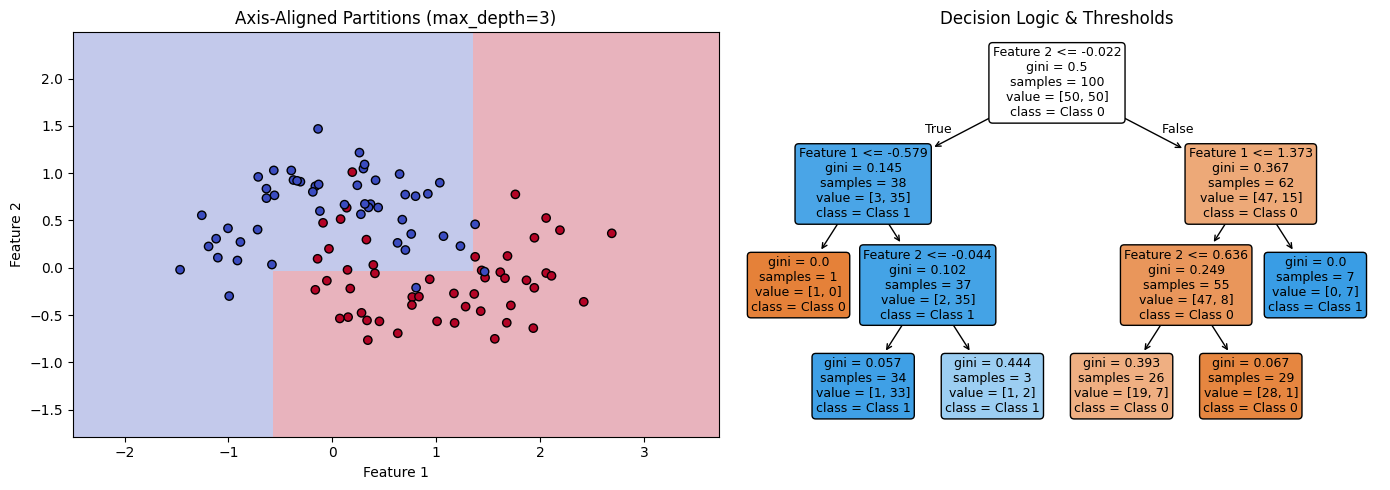

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Generate non-linear 2D dataset
X, y = make_moons(n_samples=100, noise=0.25, random_state=42)

# 2. Fit Decision Tree with a depth constraint
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X, y)

# 3. Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Decision Boundary in 2D space
DecisionBoundaryDisplay.from_estimator(
    tree_clf,
    X,
    response_method="predict",
    plot_method="pcolormesh",
    cmap="coolwarm",
    alpha=0.3,
    ax=axes[0],
)
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
axes[0].set_title("Axis-Aligned Partitions (max_depth=3)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Plot B: Internal Tree Structure
plot_tree(
    tree_clf,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    filled=True,
    fontsize=9,
    ax=axes[1],
)
axes[1].set_title("Decision Logic & Thresholds")

plt.tight_layout()
plt.show()